# Vehicle Damage Detection & Severity — Colab (data from Kaggle)

```
================================================================================
 Vehicle Damage Detection & Severity — COLAB (data pulled from Kaggle)
================================================================================
Each block below is ONE Colab cell. Run them top to bottom.

This version runs in Google Colab but downloads the 2.9 GB CarDD dataset
directly from Kaggle via the API (no slow Drive upload). You only upload the
small 21.6 MB bundle (best_model.pt + your hand-labeled crops).

ONE-TIME PREP — get a Kaggle API token:
  1. kaggle.com -> avatar -> Settings -> API -> "Create New Token".
  2. Copy the KGAT_... value. Snippet 1 will prompt you to paste it (hidden).

For Snippet 2: open the Files panel (folder icon, left sidebar) and DRAG
kaggle/upload_to_kaggle.zip into it. (Do NOT use the files.upload() widget —
it crashes the browser on files this size.)

This trains the severity model on your 195 hand-labeled crops only — no
auto-labeling step, no .cache() — so it won't run out of RAM.

Set Colab Runtime > Change runtime type > T4 GPU before running.
================================================================================
```

## SNIPPET 1 — GPU check + install + Kaggle token

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available(), "|",
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

get_ipython().system('pip -q install ultralytics==8.* kaggle >/dev/null')

# Kaggle's new tokens are a KGAT_... string (Settings > API > Create New Token).
# getpass hides it as you type — paste it at the prompt, do NOT hardcode it here.
import os, getpass
os.environ['KAGGLE_API_TOKEN'] = getpass.getpass("Paste your Kaggle token (KGAT_...): ").strip()
print("Kaggle token set.")

CUDA available: True | Tesla T4
Paste your Kaggle token (KGAT_...): ··········
Kaggle token set.


## SNIPPET 2 — Unpack your bundle (drag the zip into the Files panel)

In [7]:
from google.colab import files
import os, zipfile

print("Click 'Choose Files' and pick upload_to_kaggle.zip:")
uploaded = files.upload()                      # browse + pick the zip

# files.upload() returns {filename: bytes}; write whatever came back to disk
name = next(iter(uploaded))
with open('/content/upload_to_kaggle.zip', 'wb') as f:
    f.write(uploaded[name])
print("Saved:", name, os.path.getsize('/content/upload_to_kaggle.zip'), "bytes")

os.makedirs('/content/mydata', exist_ok=True)
with zipfile.ZipFile('/content/upload_to_kaggle.zip') as z:
    z.extractall('/content/mydata')
print("Extracted to /content/mydata:", sorted(os.listdir('/content/mydata')))
for c in ['minor', 'moderate', 'severe']:
    p = f'/content/mydata/{c}'
    print(f"  {c}: {len(os.listdir(p)) if os.path.isdir(p) else 'MISSING'}")


Click 'Choose Files' and pick upload_to_kaggle.zip:


Saving upload_to_kaggle.zip to upload_to_kaggle.zip
Saved: upload_to_kaggle.zip 21630378 bytes
Extracted to /content/mydata: ['best_model.pt', 'minor', 'moderate', 'severe']
  minor: 59
  moderate: 47
  severe: 89


## SNIPPET 3 — Download the CarDD dataset from Kaggle

In [8]:
# If this slug 404s, run:  !kaggle datasets list -s "cardd yolo"
# and replace DATASET_SLUG with the owner/name it prints.
DATASET_SLUG = 'gabrielfcarvalho/cardd-with-yolo-annotations-images-labels'
os.makedirs('/content/cardd', exist_ok=True)
get_ipython().system(f'kaggle datasets download -d {DATASET_SLUG} -p /content/cardd --unzip')
# Locate the folder that actually contains train/images
CARDD = None
for root, dirs, _ in os.walk('/content/cardd'):
    if 'train' in dirs and os.path.isdir(os.path.join(root, 'train', 'images')):
        CARDD = root
        break
print("CARDD root:", CARDD)
print("train images:", len(os.listdir(os.path.join(CARDD, 'train/images'))))

Dataset URL: https://www.kaggle.com/datasets/gabrielfcarvalho/cardd-with-yolo-annotations-images-labels
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 2.80G/2.80G [00:38<00:00, 77.7MB/s]

CARDD root: /content/cardd
train images: 2816


## SNIPPET 4 — Set working paths + write corrected data.yaml

In [9]:
WORK = '/content/work'
os.makedirs(WORK, exist_ok=True)
os.chdir(WORK)
HAND = '/content/mydata'                              # minor/ moderate/ severe/
BEST = os.path.join(HAND, 'best_model.pt')
print("Detector weights:", BEST, "exists:", os.path.exists(BEST))
for c in ['minor', 'moderate', 'severe']:
    p = os.path.join(HAND, c)
    print(f"  {c}: {len(os.listdir(p)) if os.path.isdir(p) else 'MISSING'}")

DATA_YAML = os.path.join(WORK, 'data.yaml')
with open(DATA_YAML, 'w') as f:
    f.write(f"""path: {CARDD}
train: train/images
val: val/images
test: test/images
nc: 6
names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat
""")
print(open(DATA_YAML).read())

Detector weights: /content/mydata/best_model.pt exists: True
  minor: 59
  moderate: 47
  severe: 89
path: /content/cardd
train: train/images
val: val/images
test: test/images
nc: 6
names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



## SNIPPET 5 — Validate the recovered detector

In [10]:
# If this prints GOOD, SKIP snippet 6. If WEAK, run snippet 6.
from ultralytics import YOLO

detector = None
try:
    detector = YOLO(BEST)
    print("Loaded best_model.pt. Validating on the test split...")
    m = detector.val(data=DATA_YAML, split='test', verbose=False)
    print(f"\nRecovered weights — mAP@50={m.box.map50:.3f}  mAP@50-95={m.box.map:.3f}  "
          f"P={m.box.mp:.3f}  R={m.box.mr:.3f}")
    GOOD = m.box.map50 > 0.40
    print("\n>>> Weights look GOOD — skip snippet 6." if GOOD
          else "\n>>> Weights look WEAK — run snippet 6.")
except Exception as e:
    print("Could not validate recovered weights:", e)
    print(">>> Run snippet 6.")
    GOOD = False

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loaded best_model.pt. Validating on the test split...
Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3126.3±1464.1 MB/s, size: 675.5 KB)
val: Scanning /content/cardd/test/labels... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 1.7Kit/s 0.2s
val: New cache created: /content/cardd/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 4% ──────────── 1/24 1.4it/s 0.5s<16.9s
Could not validate recovered weights: index 5 is out of bounds for axis 1 wit

## SNIPPET 6 — Retrain detector (ONLY if snippet 5 said WEAK; ~30 min)

In [11]:
import shutil
model = YOLO('yolov8n.pt')
model.train(
    data=DATA_YAML, epochs=30, imgsz=640, batch=16,
    device=0 if torch.cuda.is_available() else 'cpu',
    patience=10, project=WORK + '/runs', name='cardd_detector', exist_ok=True,
)
m = model.val(data=DATA_YAML, split='test', verbose=False)
print(f"Retrained — mAP@50={m.box.map50:.3f}  mAP@50-95={m.box.map:.3f}")
BEST = WORK + '/runs/cardd_detector/weights/best.pt'
shutil.copy(BEST, WORK + '/best_model.pt')
detector = YOLO(BEST)
print("Saved new best_model.pt")

Ultralytics 8.4.81 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/work/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cardd_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

## SNIPPET 7 — Train the severity classifier (MobileNetV2, hand-labels)

In [15]:
# Trains on your 195 hand-labeled crops only (minor/moderate/severe).
# STRATIFIED split: 20% of EACH class goes to val, so val has all 3 classes.
# (The old validation_split split by file order -> val was ~all 'severe' and
#  the 97% accuracy was an artifact. This fixes that.)
# class_weight handles the 59/47/89 imbalance. No .cache() -> low RAM.
import cv2, numpy as np, random
import tensorflow as tf
from pathlib import Path
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from sklearn.utils.class_weight import compute_class_weight

DAMAGE_NAMES = ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']
CLASSES = ['minor', 'moderate', 'severe']
IMG, BATCH = (224, 224), 16

# Build a stratified file list: per class, 20% -> val, 80% -> train.
random.seed(42)
train_files, train_lab, val_files, val_lab = [], [], [], []
for ci, c in enumerate(CLASSES):
    fs = [str(f) for f in (Path(HAND) / c).iterdir()
          if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    random.shuffle(fs)
    k = max(1, round(len(fs) * 0.2))
    val_files += fs[:k];   val_lab += [ci] * k
    train_files += fs[k:]; train_lab += [ci] * (len(fs) - k)
print("Train per class:", {c: train_lab.count(i) for i, c in enumerate(CLASSES)})
print("Val   per class:", {c: val_lab.count(i) for i, c in enumerate(CLASSES)})

def load(path, label):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.resize(img, IMG)
    return img, label

def make_ds(files, labs, training):
    ds = tf.data.Dataset.from_tensor_slices((files, labs))
    if training:
        ds = ds.shuffle(len(files), seed=42)
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_files, train_lab, True)
val_ds = make_ds(val_files, val_lab, False)

cw = compute_class_weight('balanced', classes=np.arange(3), y=np.array(train_lab))
class_weight = {i: float(w) for i, w in enumerate(cw)}
print("class_weight:", class_weight)

aug = models.Sequential([layers.RandomFlip('horizontal'),
                         layers.RandomRotation(0.1), layers.RandomZoom(0.1)])
base = MobileNetV2(input_shape=IMG + (3,), include_top=False, weights='imagenet')
base.trainable = False
model = models.Sequential([
    layers.Rescaling(1 / 127.5, offset=-1), aug, base,
    layers.GlobalAveragePooling2D(), layers.Dropout(0.3),
    layers.Dense(len(CLASSES), activation='softmax')])
model.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])
hist = model.fit(train_ds, validation_data=val_ds, epochs=25, class_weight=class_weight,
                 callbacks=[tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)])
print("\nBest val accuracy:", round(max(hist.history['val_accuracy']), 3))
model.save(WORK + '/severity_model.h5')
open(WORK + '/severity_classes.txt', 'w').write("\n".join(CLASSES))
print("Saved severity_model.h5")

Train per class: {'minor': 47, 'moderate': 38, 'severe': 71}
Val   per class: {'minor': 12, 'moderate': 9, 'severe': 18}
class_weight: {0: 1.1063829787234043, 1: 1.368421052631579, 2: 0.7323943661971831}
Epoch 1/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 224ms/step - accuracy: 0.3205 - loss: 1.4385 - val_accuracy: 0.5385 - val_loss: 1.0797
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4744 - loss: 1.2006 - val_accuracy: 0.5897 - val_loss: 0.8680
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.4808 - loss: 1.1140 - val_accuracy: 0.6410 - val_loss: 0.9551
Epoch 4/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5897 - loss: 0.9199 - val_accuracy: 0.6410 - val_loss: 0.7263
Epoch 5/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.6346 - loss: 0.8635 - val_accuracy: 0.6154 - val_loss: 0.9237
Epoch 6/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6538 - loss: 0.7508 - val_accuracy: 0.6667 - val_loss: 0.7577
Epoch 7/25
10/10 ━━━━━━━━━━━━━━━━


Best val accuracy: 0.769
Saved severity_model.h5


## SNIPPET 8 — Confusion matrix on the trusted hand-labeled val set

In [ ]:
y_true, y_pred = [], []
for x, y in val_ds:
    p = model.predict(x, verbose=0)
    y_true += list(y.numpy())
    y_pred += list(p.argmax(1))
cm = np.zeros((3, 3), int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1
print("rows=true, cols=pred  order:", CLASSES)
print(cm)
overall = float(np.trace(cm) / cm.sum()) if cm.sum() else 0
print("\nval accuracy (hand-labeled):", round(overall, 3))
# Per-class recall — exposes any single-class collapse (the old 97% bug).
for i, c in enumerate(CLASSES):
    n = cm[i].sum()
    print(f"  {c:9s} recall: {cm[i, i] / n:.2f}  (n={n})" if n else f"  {c:9s}: no val samples")

## SNIPPET 9 — End-to-end demo

000012.jpg: 1 regions -> [('tire flat', 'severe')]


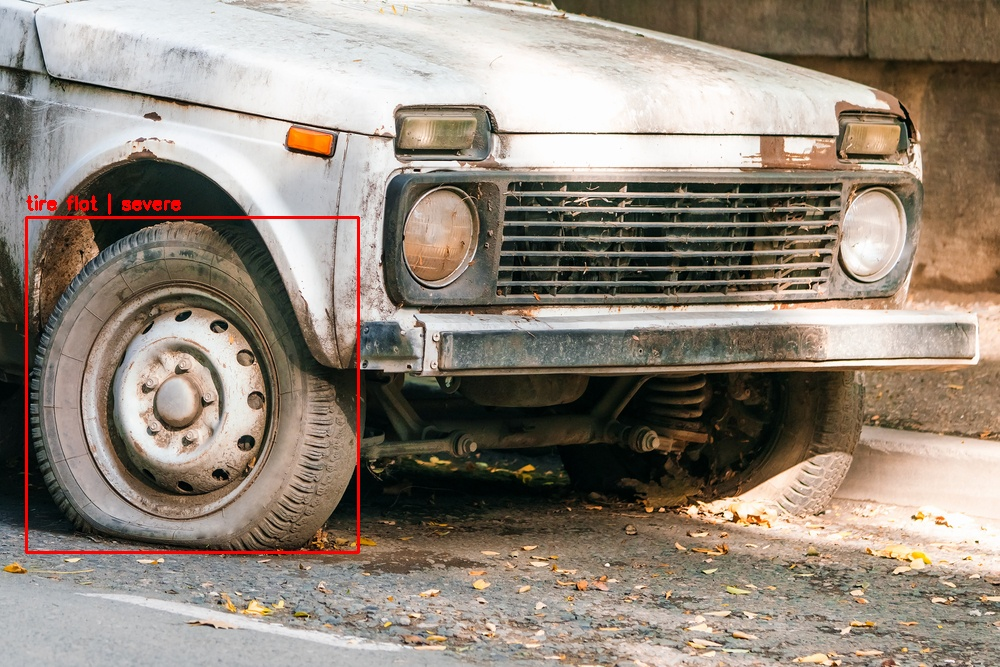

000015.jpg: 0 regions -> []


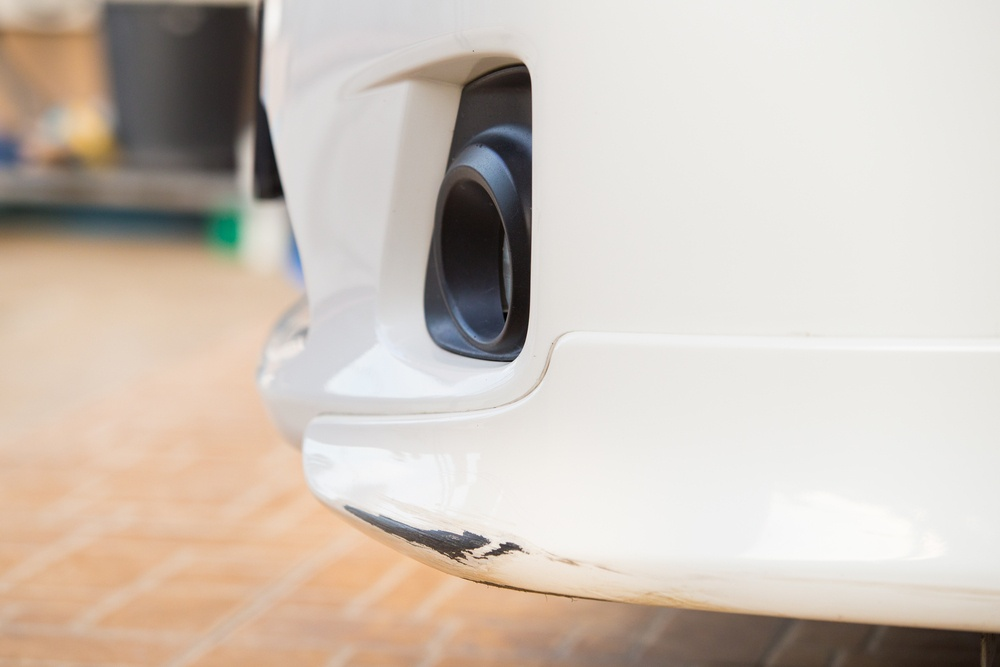

000023.jpg: 1 regions -> [('dent', 'minor')]


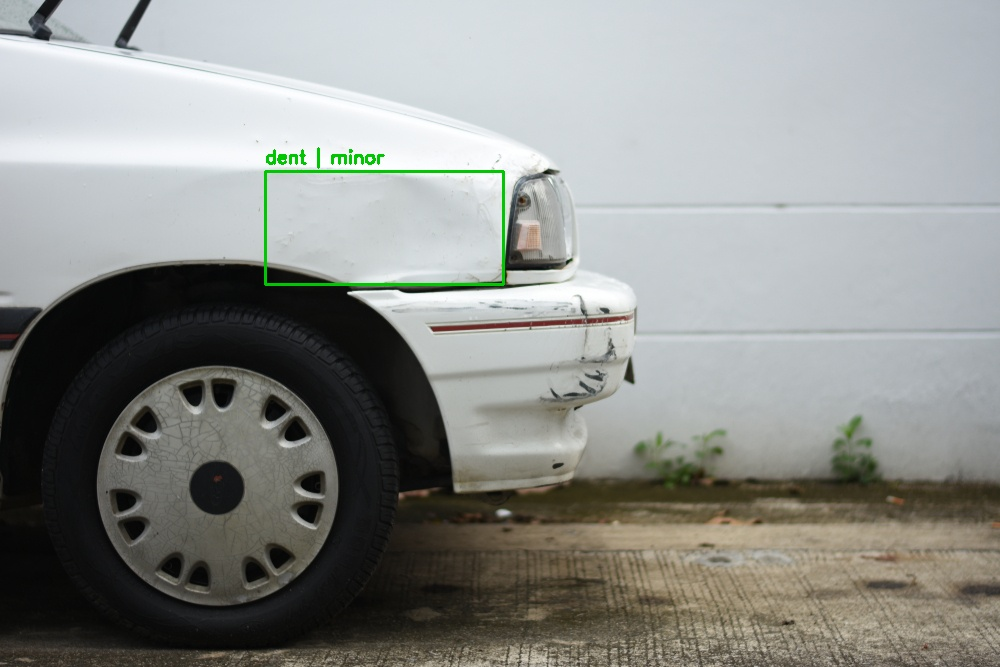

In [14]:
import glob
from IPython.display import Image as IPyImage, display

COLORS = {'minor': (0, 200, 0), 'moderate': (0, 165, 255), 'severe': (0, 0, 255)}
SEV = open(WORK + '/severity_classes.txt').read().split()

def assess(image_path, out):
    img = cv2.imread(image_path)
    assert img is not None, image_path
    found = []
    for r in detector(img, conf=0.30, verbose=False):
        if r.boxes is None:
            continue
        for b in r.boxes:
            x1, y1, x2, y2 = map(int, b.xyxy[0])
            if x2 <= x1 or y2 <= y1:
                continue
            dmg = DAMAGE_NAMES[int(b.cls[0])]
            crop = cv2.resize(img[y1:y2, x1:x2], (224, 224)).astype('float32')
            sev = SEV[int(model.predict(crop[None], verbose=0)[0].argmax())]
            col = COLORS.get(sev, (255, 255, 255))
            cv2.rectangle(img, (x1, y1), (x2, y2), col, 2)
            cv2.putText(img, f"{dmg} | {sev}", (x1, max(15, y1 - 8)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
            found.append((dmg, sev))
    cv2.imwrite(out, img)
    print(f"{os.path.basename(image_path)}: {len(found)} regions ->", found)
    return out

tests = sorted(glob.glob(os.path.join(CARDD, 'test/images/*.jpg')))[:3]
for i, t in enumerate(tests):
    o = assess(t, WORK + f'/demo_{i}.jpg')
    display(IPyImage(o))

# Download demo_0.jpg + severity_model.h5 + best_model.pt from the Files panel
# (left sidebar, /content/work), then send me your metrics to finish the README.